In [ ]:
import pandas as pd

In [ ]:
csv_file_path = "es_data.csv"

df = pd.read_csv(csv_file_path)
df.head()

,id,course_of_study,full_bio,full_image_url,industries,name,organisation,role,school,thumbnail_image_url,wave_id,last_modified_time
0,reclM5g8XAgk138Q1,Mechanical Engineering,"Chinmay Gavankar is Director, Data and Artific...",https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Chinmay Gavankar,Microsoft Corporation,Director-Data & AI,VJTI University of Mumbai,https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T15:01:44.000Z
1,recuMGexISFZy6MkF,"Master of Business Administration, B.Eng in Me...",Denis Koh is the Professional Service Director...,https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Denis Koh,"Aptos Software Singapore,",Professional Service Director,"University of Technology, Syndey, Nanyang Tech...",https://advisorysg-mentorship.s3.ap-southeast-...,2021-2,2023-04-01T01:25:57.000Z
2,rec7OJSBJ8rCSqJRI,Banking and Finance,Yee Choon Yin is a Senior Associate within the...,https://advisorysg-mentorship.s3.ap-southeast-...,['Banking and Finance'],Choon Yin Yee,DBS,senior associate,Singapore Institute of Management - University...,https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T15:36:41.000Z
3,recP44ctWCcSvn1Qr,Bachelor of Accountancy,"In his capacity as a Compliance Testing, Vice ...",https://advisorysg-mentorship.s3.ap-southeast-...,['Banking and Finance'],Derek Chee,Citibank,"Compliance Testing, Vice President",Nanyang Technological University,https://advisorysg-mentorship.s3.ap-southeast-...,2021-2,2023-04-01T01:25:57.000Z
4,rec5gZPt1aMIwwmtG,"Master of Business Administration, Masters of ...",Christian Xia is a consultant at Boston Consul...,https://advisorysg-mentorship.s3.ap-southeast-...,['Consultancy' 'Climate Change & Sustainabilit...,Christian Xia,Boston Consulting Group,Consultant,"INSEAD, National University of Singapore, Nany...",https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T14:55:04.000Z


In [ ]:
df = df[['id', 'full_bio', 'industries', 'organisation']]
df.head()

,id,full_bio,industries,organisation
0,reclM5g8XAgk138Q1,"Chinmay Gavankar is Director, Data and Artific...",['Information and Communications Technology' '...,Microsoft Corporation
1,recuMGexISFZy6MkF,Denis Koh is the Professional Service Director...,['Information and Communications Technology' '...,"Aptos Software Singapore,"
2,rec7OJSBJ8rCSqJRI,Yee Choon Yin is a Senior Associate within the...,['Banking and Finance'],DBS
3,recP44ctWCcSvn1Qr,"In his capacity as a Compliance Testing, Vice ...",['Banking and Finance'],Citibank
4,rec5gZPt1aMIwwmtG,Christian Xia is a consultant at Boston Consul...,['Consultancy' 'Climate Change & Sustainabilit...,Boston Consulting Group


In [ ]:
# randomly chosen description
RANDOM_IDX = 42
random_row = df.iloc[RANDOM_IDX]

full_bio_text = random_row['full_bio']
full_bio_text

'Effendy Ibrahim is currently the Vice President of APJ Marketing at Alteryx, a NYSE-listed software company specialising in the field of analytics automation. In this role, he leads a team of 15 across the Asia Pacific and Japan geography, leading all marketing programs and execution. Prior to this, Effendy has also served in the same capacity in software companies like Google Cloud, Veeam and Symantec. Effendy graduated from Nanyang Technological University with a Bachelor of Business and also holds a MBA from the University of Manchester.'

# 1. Topic Identification

In [ ]:
import spacy

In [ ]:
# Load the spaCy model
spacy_nlp = spacy.load("en_core_web_sm")

In [ ]:
from collections import Counter

In [ ]:
def extract_keywords(text, top_n=50, least_common=False):
    """
    Extracts the top N most specific keywords from the text using spaCy.  Specificity is determined by excluding common words
    and prioritizing nouns and noun phrases.

    Args:
        text (str): The input text.
        top_n (int): The number of top keywords to return.

    Returns:
        list: A list of the top N most specific keywords.
    """
    doc = spacy_nlp(text)
    # 1. Filter out common words and punctuation, and prioritize nouns
    specific_words = [
        token.text.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and token.pos_ in ('NOUN', 'PROPN')
    ]

    # 2.  Extract noun phrases
    articles = {"a", "an", "the", "this", "and"}
    noun_phrases = [
        " ".join(word.text.lower() for word in chunk if word.text.lower() not in articles) # changed word.lower() to word.text.lower()
        for chunk in doc.noun_chunks
        if chunk.root.pos_ in ('NOUN', 'PROPN')
    ]

    # 3. Combine and count word occurrences
    all_potential_keywords = specific_words + noun_phrases
    word_counts = Counter(all_potential_keywords)

    # 4. Get the top N keywords
    if least_common:
        top_keywords = word_counts.most_common()[:-top_n-1:-1]  # Get the least common
    else:
        top_keywords = word_counts.most_common(top_n)  # Get the most common

    return [word for word, count in top_keywords]

In [ ]:
keywords = extract_keywords(full_bio_text, top_n=25, least_common=True)
print(f"Top keywords:")
# print(keywords)
print(', '.join(keywords))
print('')

Top keywords:
nanyang technological university, google cloud, software companies, same capacity, all marketing programs, asia pacific japan geography, analytics automation, nyse - listed software company, apj marketing, vice president, effendy ibrahim, technological, nanyang, cloud, google, companies, capacity, programs, geography, japan, pacific, asia, automation, analytics, company



Topic Identification (TI), K=25

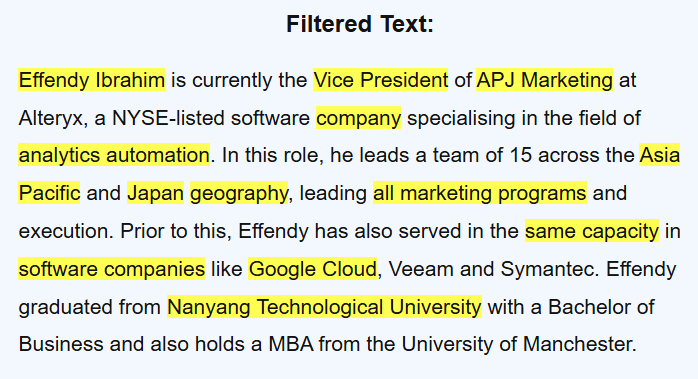

In [ ]:
keywords = extract_keywords(full_bio_text, top_n=35, least_common=True)
print(f"Top keywords:")
# print(keywords)
print(', '.join(keywords))
print('')

Top keywords:
nanyang technological university, google cloud, software companies, same capacity, all marketing programs, asia pacific japan geography, analytics automation, nyse - listed software company, apj marketing, vice president, effendy ibrahim, technological, nanyang, cloud, google, companies, capacity, programs, geography, japan, pacific, asia, automation, analytics, company, nyse, apj, president, vice, ibrahim, manchester, mba, business, bachelor, veeam



TI, K=35

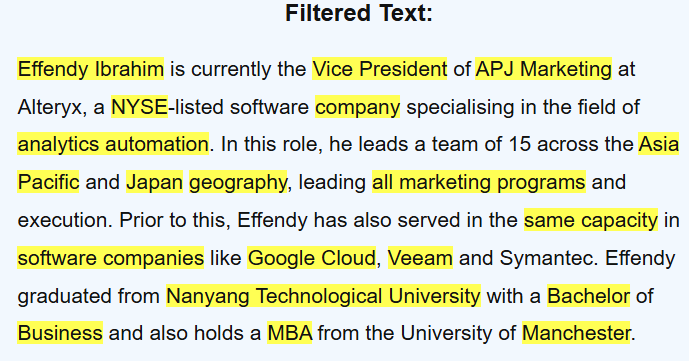

In [ ]:
keywords = extract_keywords(full_bio_text, top_n=50, least_common=True)
print(f"Top keywords:")
# print(keywords)
print(', '.join(keywords))
print('')

Top keywords:
nanyang technological university, google cloud, software companies, same capacity, all marketing programs, asia pacific japan geography, analytics automation, nyse - listed software company, apj marketing, vice president, effendy ibrahim, technological, nanyang, cloud, google, companies, capacity, programs, geography, japan, pacific, asia, automation, analytics, company, nyse, apj, president, vice, ibrahim, manchester, mba, business, bachelor, veeam, execution, team, role, field, software, alteryx, marketing, university, effendy



TI, K=50

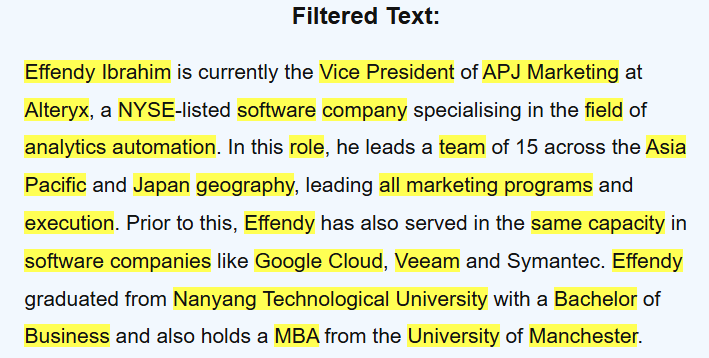

# 2. NER using StanfordCore

In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12


In [ ]:
import stanza

In [ ]:
# Initialize the pipeline
nlp_stanza = stanza.Pipeline('en', processors='tokenize,ner')

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json


INFO:stanza:Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| ner       | ontonotes-ww-multi_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


In [ ]:
def process_text_with_stanza_ner(text, nlp_model):
    """
    Processes the given text using the provided StanfordNLP model to extract
    named entities and tokens with their NER tags.

    Args:
        text (str): The text to process.
        nlp_model (Pipeline): A pre-initialized StanfordNLP Pipeline object.

    Returns:
        dict: A dictionary containing the extracted information with two keys:
            - 'named_entities': A list of dictionaries, where each dictionary
              represents a named entity and has 'text' and 'type' keys.
            - 'tokens_with_ner_tags': A list of dictionaries, where each dictionary
              represents a token and has 'token' and 'ner_tag' keys.
              Returns empty lists if no entities or tokens are found.
    """
    doc = nlp_stanza(text)  # Process the text

    named_entities = []
    for ent in doc.ents:
        if ent.type != 'CARDINAL':  # Exclude CARDINAL entities here
            named_entities.append({
                'text': ent.text,
                'type': ent.type
            })

    tokens_with_ner_tags = []
    for sentence in doc.sentences:
        for token in sentence.tokens:
            tokens_with_ner_tags.append({
                'token': token.text,
                'ner_tag': token.ner  # Stanza uses .ner for NER tag
            })

    return {
        'named_entities': named_entities,
        'tokens_with_ner_tags': tokens_with_ner_tags
    }

In [ ]:
import time

In [ ]:
start_time = time.time()

results = process_text_with_stanza_ner(full_bio_text, nlp_stanza)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

# Print Named Entities
print("Named Entities:")
if results['named_entities']:
    for entity in results['named_entities']:
        print(f"Entity: {entity['text']}, Type: {entity['type']}")
else:
    print("No named entities found.")

Calculation took 1.0314 seconds.
Named Entities:
Entity: Effendy Ibrahim, Type: PERSON
Entity: APJ Marketing, Type: ORG
Entity: Alteryx, Type: ORG
Entity: NYSE, Type: ORG
Entity: the Asia Pacific, Type: LOC
Entity: Japan, Type: GPE
Entity: Effendy, Type: ORG
Entity: Google Cloud, Type: ORG
Entity: Veeam, Type: ORG
Entity: Symantec, Type: ORG
Entity: Effendy, Type: PERSON
Entity: Nanyang Technological University, Type: ORG
Entity: MBA, Type: WORK_OF_ART
Entity: the University of Manchester, Type: ORG


In [ ]:
entity_texts = [entity['text'] for entity in results['named_entities']] # Extract entity texts into a list
print(entity_texts)

['Effendy Ibrahim', 'APJ Marketing', 'Alteryx', 'NYSE', 'the Asia Pacific', 'Japan', 'Effendy', 'Google Cloud', 'Veeam', 'Symantec', 'Effendy', 'Nanyang Technological University', 'MBA', 'the University of Manchester']


# 3. Combining NER with TI

Choosing TI with K=35

In [ ]:
def extract_keywords(text, top_n=35):
    """
    Extracts the top N most specific keywords from the text using spaCy.  Specificity is determined by excluding common words
    and prioritizing nouns and noun phrases.

    Args:
        text (str): The input text.
        top_n (int): The number of top keywords to return.

    Returns:
        list: A list of the top N most specific keywords.
    """
    doc = spacy_nlp(text)
    # 1. Filter out common words and punctuation, and prioritize nouns
    specific_words = [
        token.text.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and token.pos_ in ('NOUN', 'PROPN')
    ]

    # 2.  Extract noun phrases
    articles = {"a", "an", "the", "this", "and"}
    noun_phrases = [
        " ".join(word.text.lower() for word in chunk if word.text.lower() not in articles)
        for chunk in doc.noun_chunks
        if chunk.root.pos_ in ('NOUN', 'PROPN')
    ]

    # 3. Combine and count word occurrences
    all_potential_keywords = specific_words + noun_phrases
    word_counts = Counter(all_potential_keywords)

    # 4. Get the top keywords
    top_keywords = word_counts.most_common()[:-top_n-1:-1]  # Get the least common

    return [word for word, count in top_keywords]

def stanza_ner(text, nlp_stanza):
    """
    Processes the input text with Stanza for Named Entity Recognition (NER)
    and returns the entity texts as a list, excluding 'CARDINAL' entities.

    Args:
        text (str): The text to process.
        nlp: The Stanza NLP pipeline object.

    Returns:
        list: A list of extracted entity texts, excluding 'CARDINAL' entities.
            Returns an empty list if no entities are found.
    """
    doc = nlp_stanza(text)
    entity_texts = [ent.text for ent in doc.ents if ent.type != 'CARDINAL']  # Exclude CARDINAL entities
    return entity_texts

In [ ]:
def combine_keywords_and_ner(text):
    """
    Combines keywords and NER entities extracted from the given text.

    Args:
        text (str): The input text.

    Returns:
        set: A set containing unique keywords and named entities.
    """
    # Check if the input is a string
    if isinstance(text, str):
        keywords = extract_keywords(text)
        ner_entities = stanza_ner(text, nlp_stanza)

        # Combine keywords and NER entities, removing duplicates
        combined_results = list(set(keywords + ner_entities))
        return combined_results
    else:
        # Handle non-string inputs (e.g., NaN)
        return []  # or any other appropriate value

In [ ]:
start_time = time.time()

combined_results = combine_keywords_and_ner(full_bio_text)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("Combined Keywords and NER Entities:")
print(combined_results)
print(', '.join(combined_results))
print('')

Calculation took 1.0594 seconds.
Combined Keywords and NER Entities:
['company', 'veeam', 'Effendy Ibrahim', 'google cloud', 'Alteryx', 'ibrahim', 'nanyang', 'nyse', 'APJ Marketing', 'Effendy', 'president', 'Symantec', 'analytics automation', 'companies', 'geography', 'capacity', 'Japan', 'the Asia Pacific', 'MBA', 'google', 'software companies', 'same capacity', 'manchester', 'bachelor', 'asia', 'nanyang technological university', 'effendy ibrahim', 'automation', 'Nanyang Technological University', 'the University of Manchester', 'analytics', 'Google Cloud', 'business', 'japan', 'cloud', 'vice president', 'mba', 'NYSE', 'asia pacific japan geography', 'technological', 'all marketing programs', 'apj marketing', 'Veeam', 'programs', 'nyse - listed software company', 'vice', 'pacific', 'apj']
company, veeam, Effendy Ibrahim, google cloud, Alteryx, ibrahim, nanyang, nyse, APJ Marketing, Effendy, president, Symantec, analytics automation, companies, geography, capacity, Japan, the Asia Pac

In [ ]:
print(', '.join(combined_results))
print('')

company, veeam, Effendy Ibrahim, google cloud, Alteryx, ibrahim, nanyang, nyse, APJ Marketing, Effendy, president, Symantec, analytics automation, companies, geography, capacity, Japan, the Asia Pacific, MBA, google, software companies, same capacity, manchester, bachelor, asia, nanyang technological university, effendy ibrahim, automation, Nanyang Technological University, the University of Manchester, analytics, Google Cloud, business, japan, cloud, vice president, mba, NYSE, asia pacific japan geography, technological, all marketing programs, apj marketing, Veeam, programs, nyse - listed software company, vice, pacific, apj



Testing on 3 examples

In [ ]:
# randomly chosen description
RANDOM_IDX = 67
random_row = df.iloc[RANDOM_IDX]

sample_bio_text = random_row['full_bio']
sample_bio_text

'James D’Souza is a Product Technical Lead at Dyson Singapore Technology Centre, where he leads the engineering development and innovation of new technologies for Dyson’s future products. With his extensive knowledge in thermal engineering and fluid dynamics, James is proficient in technical problem solving, systems modelling, as well as experimentation. He is also effective in building and leading high performance teams at Dyson. James graduated from the University of Mumbai’s Don Bosco Institute of Technology with a Bachelor of Engineering in Mechanical Engineering, and later obtained his Master’s of Science in Mechanical Engineering at the National University of Singapore. '

In [ ]:
start_time = time.time()

combined_results = combine_keywords_and_ner(sample_bio_text)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("Combined Keywords and NER Entities:")
print(combined_results)
print(', '.join(combined_results))
print('')

Calculation took 1.5374 seconds.
Combined Keywords and NER Entities:
{'don', 'systems modelling', 'thermal engineering fluid dynamics', 'national university', 'his master', 'product technical lead', 'James', 'dyson ’s future products', 'bosco', 'Dyson', 'dynamics', 'solving', 'technologies', 'engineering development', 'teams', 'products', 'development', 'Master’s of Science in Mechanical Engineering', 'master', 'new technologies', 'the University of Mumbai’s Don Bosco Institute of Technology', 'national', 'product', 'Dyson’s', 'performance', 'the National University of Singapore', 'fluid', 'Dyson Singapore Technology Centre', 'institute', 'modelling', 'leading high performance teams', 'technical', 'technical problem solving', 'his extensive knowledge', 'centre', 'James D’Souza', 'systems', 'dyson singapore technology centre', 'james d’souza', 'lead', 'problem', 'knowledge', 'd’souza'}
don, systems modelling, thermal engineering fluid dynamics, national university, his master, product t

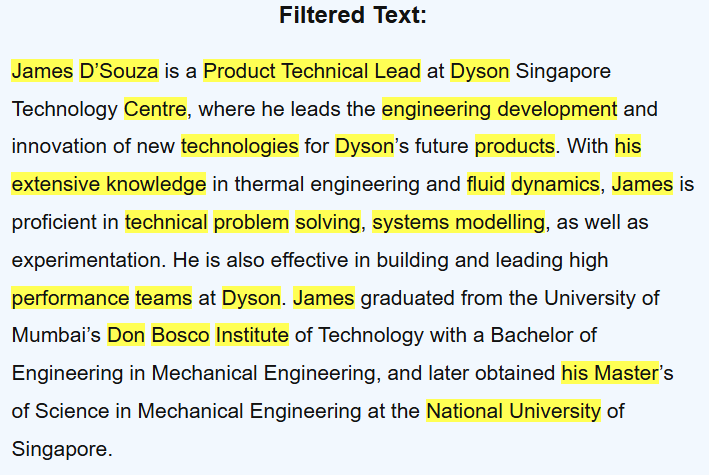

In [ ]:
# randomly chosen description
RANDOM_IDX = 128
random_row = df.iloc[RANDOM_IDX]

sample_bio_text = random_row['full_bio']
sample_bio_text

"Kyeongho Lee (Ken for short) is the Principal at Wood Mackenzie, a leading global energy advisory and consultancy. In this capacity, he provides commercial advisory and specialized power modelling for Asia Pacific markets for clients to make decisions on which renewable power technologies to invest in and assess their commercial value. He has also undertaken various strategic projects for major oil and gas companies on LNG/gas-to-power investment viability as well as for solar and wind projects. He was previously a consultant in the oil and gas sector and developer of power plants in the Philippines and Singapore. He graduated from Duke University with a Bachelor's degree in public policy studies and earned an all expenses paid-for scholarship at Duke through the Robertson Scholars Leadership Program."

In [ ]:
start_time = time.time()

combined_results = combine_keywords_and_ner(sample_bio_text)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("Combined Keywords and NER Entities:")
print(combined_results)
print(', '.join(combined_results))
print('')

Calculation took 2.1067 seconds.
Combined Keywords and NER Entities:
{'lng', 'oil gas sector', 'plants', 'Asia Pacific', 'leadership', 'specialized power modelling', 'wood mackenzie', "Bachelor's", 'public policy studies', 'Duke', 'Ken', 'the Robertson Scholars Leadership Program', 'degree', 'studies', 'various strategic projects', 'Kyeongho Lee', 'scholarship', 'major oil gas companies', 'sector', 'investment', 'Singapore', 'duke university', 'bachelor', 'their commercial value', 'kyeongho lee', 'Wood Mackenzie', 'expenses', 'policy', 'power plants', "bachelor 's degree", 'solar wind projects', 'program', 'robertson scholars leadership program', 'Duke University', 'scholars', 'asia pacific markets', 'all expenses', 'commercial advisory', 'viability', 'Philippines', 'university', 'wind', 'LNG', 'robertson', 'paid - for scholarship', 'leading global energy advisory'}
lng, oil gas sector, plants, Asia Pacific, leadership, specialized power modelling, wood mackenzie, Bachelor's, public po

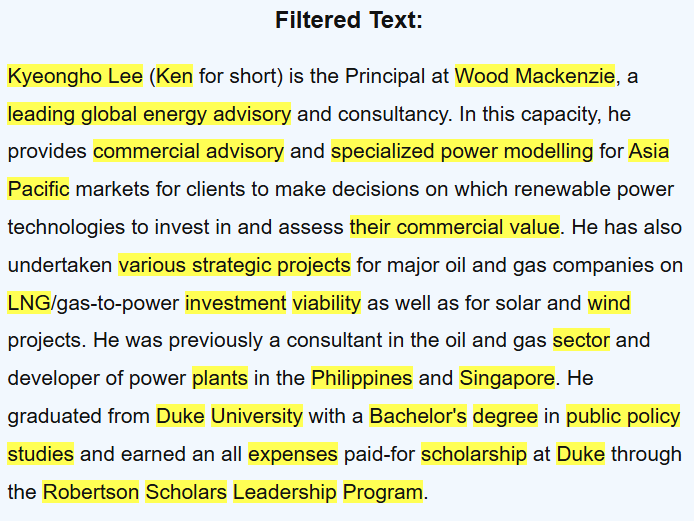

In [ ]:
# randomly chosen description
RANDOM_IDX = 289
random_row = df.iloc[RANDOM_IDX]

sample_bio_text = random_row['full_bio']
sample_bio_text

"Sandeep Mishra is Technical Architect at Credit Agricole CIB. In this capacity, he performs architecture governanace, solution design, technical stack evaluation, development, hiring and mentoring of resources— and is also an active participant in the bank's hiring initiatives such as the Butterfly and IMDA programs. Prior to this, he served as Technical Consultant at Citibank, where he performed security assessment of appications, vendor migration, design and development. He has also undertaken portfolios as software engineer in software product companies vsuch as i2 Technologies, Comsoft Infotech. He graduated from Veermata Jijabai Technological Institute with a Master of Computer Applications in Computer Science."

In [ ]:
start_time = time.time()

combined_results = combine_keywords_and_ner(sample_bio_text)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("Combined Keywords and NER Entities:")
print(combined_results)
print(', '.join(combined_results))
print('')

Calculation took 1.8905 seconds.
Combined Keywords and NER Entities:
{"bank 's hiring initiatives", 'security assessment', 'veermata', 'Comsoft Infotech', 'butterfly imda programs', 'infotech', 'Veermata Jijabai Technological Institute', 'software engineer', 'computer science', 'vendor', 'i2 Technologies', 'science', 'comsoft infotech', 'architecture governanace', 'companies', 'comsoft', 'technologies', 'credit agricole cib', 'software product companies', 'jijabai', 'product', 'assessment', 'Credit Agricole CIB', 'Butterfly', 'Citibank', 'veermata jijabai technological institute', 'solution design', 'applications', 'migration', 'institute', 'vendor migration', 'technical consultant', 'technical stack evaluation', 'i2', 'Sandeep Mishra', 'engineer', 'computer applications', 'IMDA', 'Master of Computer Applications in Computer Science', 'i2 technologies', 'technical architect', 'sandeep mishra', 'technological', 'active participant'}
bank 's hiring initiatives, security assessment, veerm

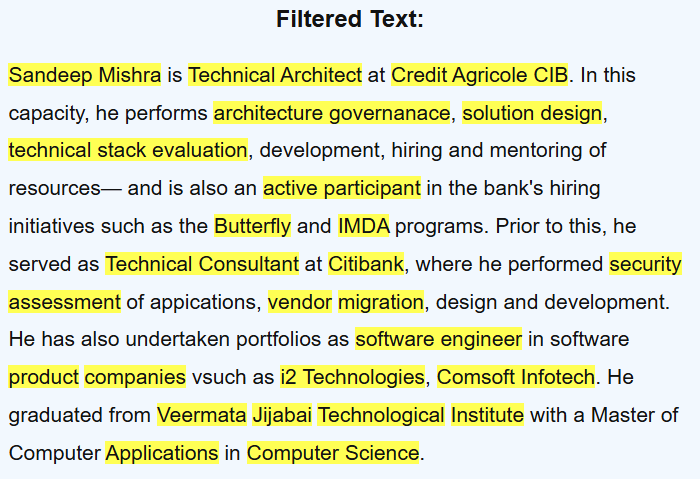

In [ ]:
df['combined_keywords'] = df['full_bio'].apply(combine_keywords_and_ner)

In [ ]:
# Save the output to a CSV file
output_csv_path = "es_mentor_with_keywords.csv"
df.to_csv(output_csv_path)
print(f"Successfully saved updated DataFrame to CSV file: {output_csv_path}")

Successfully saved updated DataFrame to CSV file: es_data_with_combined_results.csv
